In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ToTo.csv')
df.tail() # draw: from 2341 (7/3/2008) to 3831 (1/2/2023) = 1491 draws. Does not account for rules change in 2014.

,Draw,Date,Winning Number 1,2,3,4,5,6,Additional Number,From Last,...,Division 3 Winners,Division 3 Prize,Division 4 Winners,Division 4 Prize,Division 5 Winners,Division 5 Prize,Division 6 Winners,Division 6 Prize,Division 7 Winners,Division 7 Prize
1486,2345,2008-07-17,5,10,25,27,36,39,40,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1487,2344,2008-07-14,5,12,17,18,38,40,22,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1488,2343,2008-07-10,22,32,41,42,43,44,31,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1489,2342,2008-07-07,2,18,19,21,39,45,36,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1490,2341,2008-07-03,6,11,14,15,28,45,35,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
# Get every set of winning numbers
row_list = []
for index, rows in df.iterrows():
    row_list.append([rows['Winning Number 1'], rows['2'], rows['3'], rows['4'], rows['5'], rows['6'], rows['Additional Number ']])
print(row_list)

# Prepare blank matrix for number correlation
matrix = pd.DataFrame(data = [[0 for j in range(1,50)] for i in range(1,50)], index = [i for i in range(1,50)], columns = [i for i in range(1,50)])
matrix

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
# Fill up matrix
for eachrow in row_list:
    for eachno in eachrow:
        for othernos in eachrow:
            matrix[othernos][eachno] += 1 # matrix[column][row]

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
1,238,25,30,28,31,28,31,30,23,33,...,34,39,38,23,32,36,14,9,24,17
2,25,212,27,24,25,28,24,25,34,25,...,27,17,28,28,30,19,19,16,15,16
3,30,27,204,30,27,28,34,25,37,21,...,27,36,26,24,27,25,17,15,15,23
4,28,24,30,216,26,32,25,25,35,27,...,28,27,30,27,35,23,13,24,22,10
5,31,25,27,26,219,25,26,31,34,18,...,32,24,24,20,28,26,16,17,18,22
6,28,28,28,32,25,228,26,33,23,32,...,31,24,23,29,32,32,19,12,12,16
7,31,24,34,25,26,26,225,28,40,35,...,24,31,28,26,28,35,10,16,22,9
8,30,25,25,25,31,33,28,234,29,31,...,27,30,23,35,25,29,25,16,24,12
9,23,34,37,35,34,23,40,29,234,31,...,36,28,22,28,40,26,20,16,14,14
10,33,25,21,27,18,32,35,31,31,224,...,35,31,34,24,32,28,20,13,17,14


In [81]:
# Compile the frequencies of the numbers into a list, replace them in the matrix as zeros (so as not to skew the heatmap)
freqlist = []
for i in range (1,50):
    a = matrix[i][i]
    freqlist.append(a)
    matrix[i][i] = 0 #pd.NA
freqlist

[238,
 212,
 204,
 216,
 219,
 228,
 225,
 234,
 234,
 224,
 215,
 235,
 217,
 206,
 238,
 216,
 234,
 217,
 211,
 228,
 222,
 250,
 239,
 222,
 203,
 216,
 233,
 213,
 227,
 222,
 239,
 222,
 206,
 211,
 201,
 235,
 202,
 210,
 208,
 225,
 220,
 206,
 211,
 229,
 200,
 136,
 127,
 127,
 124]

<AxesSubplot:title={'center':'Correlation Heatmap: from 3/7/2008 to 2/1/2023'}>

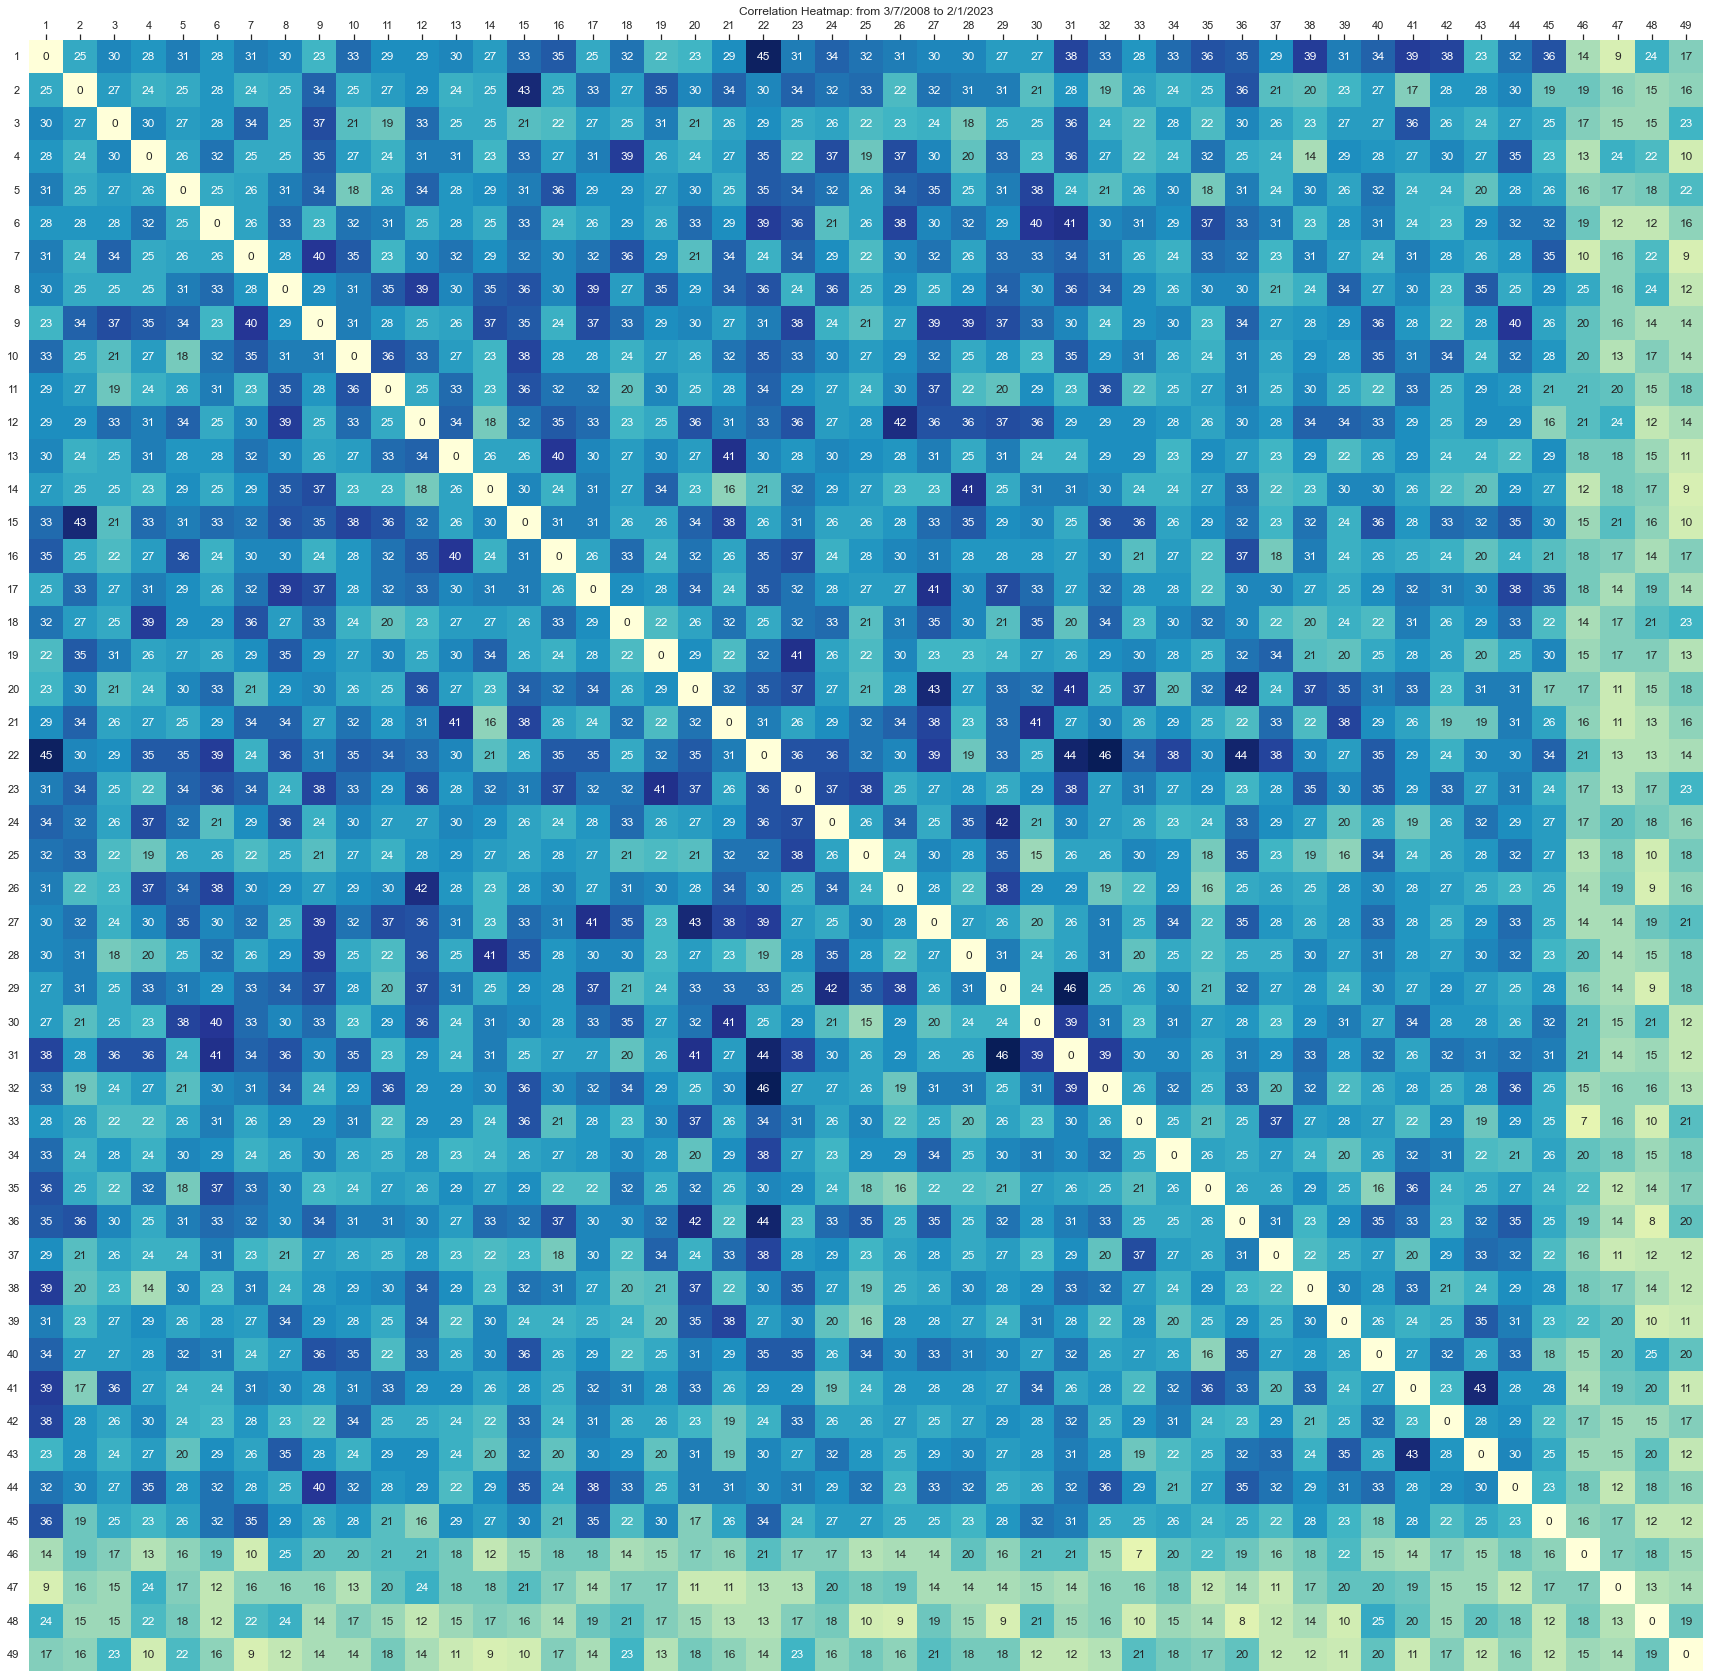

In [165]:
plt.figure(figsize=(30,30))

corrmap = sns.heatmap(matrix, cmap="YlGnBu", annot=True, cbar=False)
corrmap.set_title('Correlation Heatmap: from 3/7/2008 to 2/1/2023')
corrmap.xaxis.set_ticks_position("top") # set x axis ticks to the top
corrmap.set_yticklabels(corrmap.get_yticklabels(), rotation = 0) # make sure y axis ticks are upright
corrmap

In [166]:
corrmap.get_figure().savefig('corrmap 02012023.png', bbox_inches='tight', dpi=300) # export figure

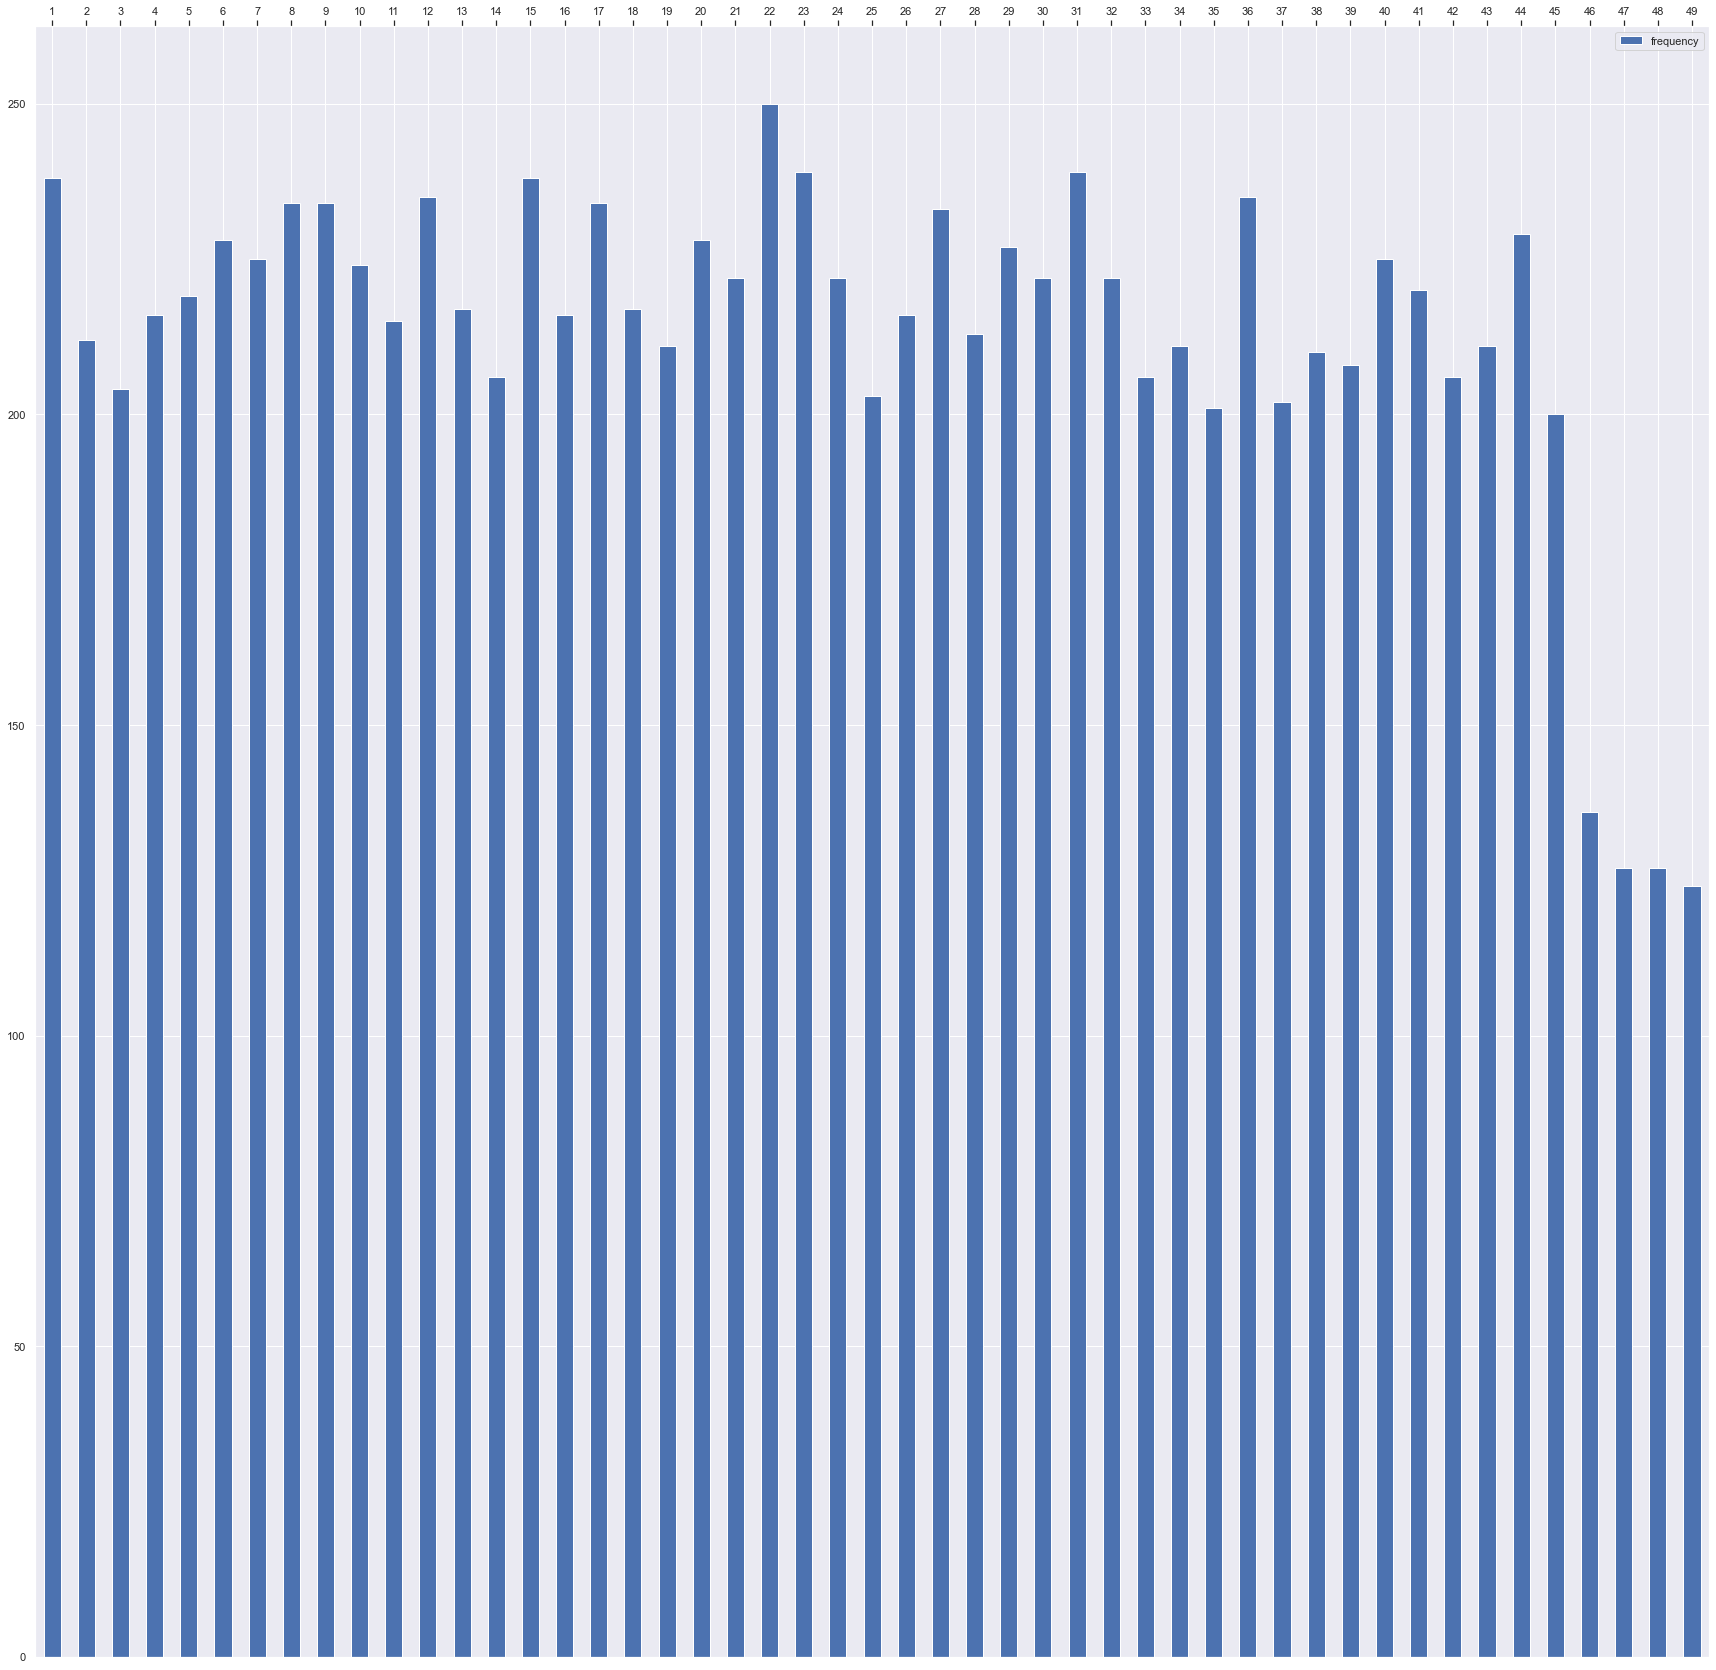

In [162]:
# Frequency analysis
df_freq = pd.DataFrame(data=freqlist, index = [i for i in range(1,50)], columns=['frequency'])

freqplot = df_freq.plot.bar(figsize=(30,20))
freqplot.xaxis.tick_top()
fig = freqplot.get_figure()
fig.savefig('freqchart.png', bbox_inches='tight', dpi=300)

In [175]:
# Sums of every draw analysis

# List of sums for all draws
drawsums = []
for eachrow in row_list:
    drawsums.append(sum([i for i in eachrow]))
print(drawsums)

# List of dates for all draws
dates_list = []
for index, rows in df.iterrows():
    dates_list.append(rows['Date'])
print(dates_list)

[160,
 197,
 208,
 131,
 205,
 140,
 165,
 179,
 114,
 179,
 167,
 123,
 147,
 162,
 182,
 187,
 206,
 161,
 174,
 206,
 170,
 148,
 145,
 99,
 200,
 147,
 186,
 268,
 193,
 188,
 144,
 207,
 192,
 135,
 128,
 225,
 102,
 126,
 217,
 145,
 206,
 154,
 193,
 189,
 172,
 144,
 182,
 221,
 199,
 161,
 164,
 181,
 122,
 188,
 217,
 227,
 196,
 148,
 160,
 151,
 207,
 221,
 187,
 171,
 138,
 144,
 221,
 206,
 128,
 181,
 167,
 141,
 189,
 181,
 243,
 154,
 150,
 130,
 214,
 153,
 133,
 133,
 123,
 197,
 260,
 201,
 204,
 204,
 176,
 158,
 175,
 190,
 183,
 108,
 168,
 217,
 144,
 190,
 159,
 145,
 171,
 142,
 179,
 167,
 213,
 121,
 123,
 227,
 128,
 228,
 174,
 210,
 226,
 177,
 127,
 173,
 121,
 200,
 207,
 158,
 145,
 202,
 140,
 202,
 224,
 180,
 198,
 176,
 221,
 217,
 163,
 174,
 252,
 243,
 118,
 152,
 221,
 204,
 176,
 118,
 183,
 206,
 158,
 168,
 171,
 193,
 200,
 139,
 164,
 161,
 204,
 192,
 173,
 100,
 194,
 116,
 153,
 108,
 240,
 142,
 129,
 176,
 181,
 123,
 188,
 164,
 146,

168.1441985244802


C:\Users\rateo\AppData\Local\Temp\ipykernel_8196\2922208080.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  sumschart.set_xticklabels(dates_list, size = 3, rotation=90)


<AxesSubplot:title={'center':'Draw sums: from 3/7/2008 to 2/1/2023. Grand mean sum: 168.1441985244802'}>

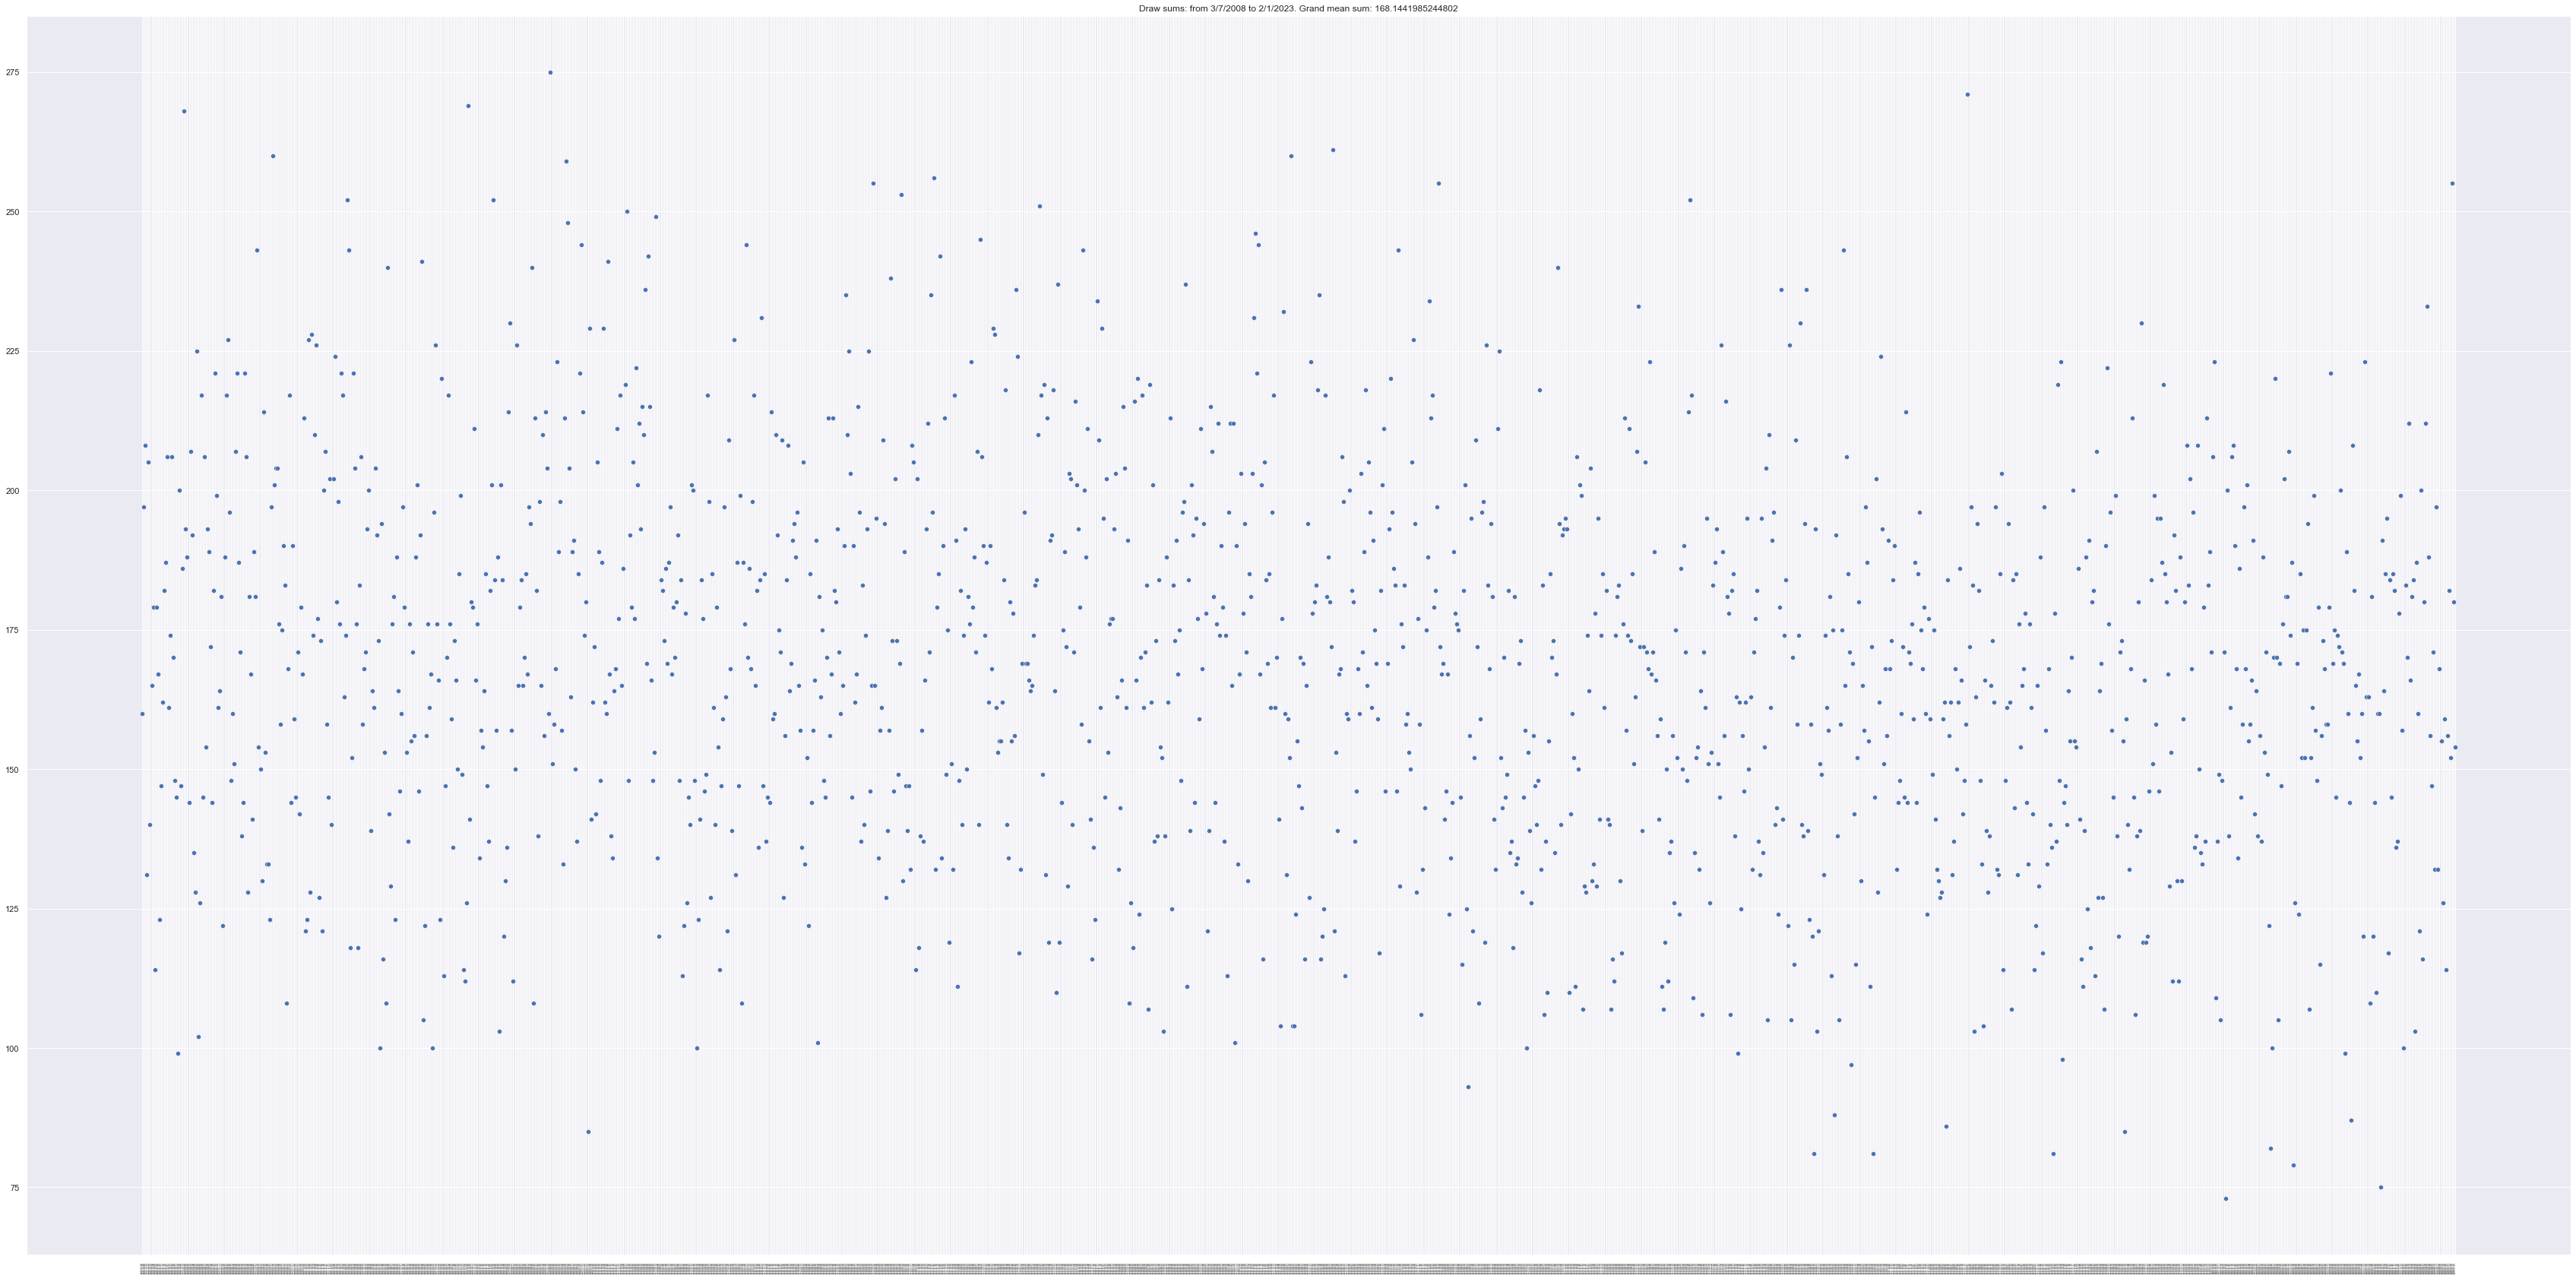

In [194]:
mean = 0
for i in drawsums:
    mean += i
mean = mean/len(drawsums)
print(mean)

plt.figure(figsize=(60,30))
sumschart = sns.scatterplot(x=dates_list, y=drawsums)
sumschart.set_xticklabels(dates_list, size = 3, rotation=90)
sumschart.set_title(f'Draw sums: from 3/7/2008 to 2/1/2023. Grand mean sum: {mean}')
sumschart

In [195]:
sumschart.get_figure().savefig('sumschart 02012023.png', bbox_inches='tight', dpi=450) # export figure

In [2]:
# REPEAT WITH SMALLER DATASET TO ACCOUNT FOR HIGHEST NUMBER CHANGE IN 2014.
# On 1 July 1997, Toto's format was changed once again to a '6 out-of 45' format. On 7 October 2014 Toto was changed to a '6 out-of 49' format.
# First draw thereafter = 2995 (9-10-2014). 837 data points.

In [3]:
df = pd.read_csv('ToTo.csv')
df2014 = df[df['Draw'] >= 2995]
df2014.tail(10)

,Draw,Date,Winning Number 1,2,3,4,5,6,Additional Number,From Last,...,Division 3 Winners,Division 3 Prize,Division 4 Winners,Division 4 Prize,Division 5 Winners,Division 5 Prize,Division 6 Winners,Division 6 Prize,Division 7 Winners,Division 7 Prize
827,3004,2014-11-10,2,16,19,29,33,42,34,2,...,145.0,1669.0,286.0,462.0,6671.0,50.0,8275.0,25.0,126240.0,10.0
828,3003,2014-11-06,2,22,24,38,46,47,9,"38,47",...,55.0,3166.0,192.0,495.0,3824.0,50.0,5943.0,25.0,77852.0,10.0
829,3002,2014-11-03,31,32,38,39,40,47,7,NaN,...,81.0,1845.0,184.0,443.0,3530.0,50.0,5164.0,25.0,63863.0,10.0
830,3001,2014-10-30,12,19,26,42,45,46,23,42,...,121.0,1853.0,288.0,425.0,6012.0,50.0,8760.0,25.0,113081.0,10.0
831,3000,2014-10-27,5,20,27,38,42,44,41,5,...,92.0,1900.0,199.0,480.0,4967.0,50.0,5927.0,25.0,95542.0,10.0
832,2999,2014-10-23,5,22,25,28,33,34,32,NaN,...,64.0,2162.0,178.0,424.0,4705.0,50.0,5774.0,25.0,81579.0,10.0
833,2998,2014-10-20,8,11,17,21,41,49,35,NaN,...,166.0,1435.0,350.0,372.0,8404.0,50.0,9021.0,25.0,148908.0,10.0
834,2997,2014-10-16,4,9,31,34,40,44,35,31,...,83.0,1974.0,216.0,414.0,5635.0,50.0,5731.0,25.0,90370.0,10.0
835,2996,2014-10-13,19,28,31,43,45,48,41,28,...,61.0,2436.0,108.0,751.0,3414.0,50.0,4846.0,25.0,69704.0,10.0
836,2995,2014-10-09,11,12,25,28,34,47,15,"12,25,34",...,95.0,2028.0,239.0,440.0,5400.0,50.0,7553.0,25.0,102478.0,10.0


In [4]:
# Get every set of winning numbers
row_list_2014 = []
for index, rows in df2014.iterrows():
    row_list_2014.append([rows['Winning Number 1'], rows['2'], rows['3'], rows['4'], rows['5'], rows['6'], rows['Additional Number ']])
print(row_list_2014)

# Prepare blank matrix for number correlation
matrix2014 = pd.DataFrame(data = [[0 for j in range(1,50)] for i in range(1,50)], index = [i for i in range(1,50)], columns = [i for i in range(1,50)])
matrix2014

[[1, 13, 15, 32, 41, 47, 11], [12, 18, 25, 28, 30, 36, 48], [3, 10, 31, 32, 44, 47, 41], [4, 11, 13, 16, 32, 46, 9], [8, 14, 24, 26, 45, 46, 42], [4, 12, 17, 19, 24, 44, 20], [3, 7, 22, 27, 44, 49, 13], [1, 6, 21, 35, 37, 46, 33], [5, 6, 7, 25, 28, 35, 8], [3, 12, 20, 39, 40, 47, 18], [7, 16, 17, 28, 37, 48, 14], [3, 8, 11, 21, 24, 31, 25], [3, 9, 21, 30, 36, 46, 2], [1, 10, 16, 23, 38, 49, 25], [8, 15, 22, 26, 34, 45, 32], [10, 23, 28, 35, 39, 46, 6], [10, 14, 33, 37, 39, 45, 28], [13, 21, 24, 25, 26, 41, 11], [4, 14, 17, 25, 29, 49, 36], [13, 16, 25, 41, 45, 46, 20], [7, 11, 17, 21, 41, 43, 30], [2, 9, 19, 27, 33, 37, 21], [1, 8, 16, 24, 38, 43, 15], [2, 4, 8, 17, 22, 40, 6], [8, 10, 18, 26, 42, 47, 49], [10, 19, 20, 22, 26, 46, 4], [7, 16, 20, 29, 33, 42, 39], [27, 29, 31, 44, 46, 49, 42], [6, 19, 24, 34, 43, 46, 21], [3, 11, 19, 26, 43, 49, 37], [1, 5, 14, 23, 40, 45, 16], [13, 15, 27, 29, 38, 45, 40], [8, 15, 21, 22, 39, 43, 44], [1, 8, 11, 12, 22, 46, 35], [4, 9, 13, 18, 34, 47, 

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Fill up matrix
for eachrow in row_list_2014:
    for eachno in eachrow:
        for othernos in eachrow:
            matrix2014[othernos][eachno] += 1 # matrix[column][row]
print(matrix2014)

# Compile the frequencies of the numbers into a list, replace them in the matrix as zeros (so as not to skew the heatmap)
freqlist2014 = []
for i in range (1,50):
    a = matrix2014[i][i]
    freqlist2014.append(a)
    matrix2014[i][i] = 0 #pd.NA
print(freqlist2014)

     1    2    3    4    5    6    7    8    9    10  ...   40   41   42   43  \
1   129   14   16   17   14   11   21   13   12   18  ...   28   21   19   11   
2    14  128   15   11   13   16   18   12   23   14  ...   17   11   12   16   
3    16   15  118   14   18   17   12   15   20   11  ...   21   20    7   12   
4    17   11   14  112   14   17    8   13   12   14  ...   17   12   10   10   
5    14   13   18   14  125   13   14   20   20    9  ...   20   12   16   10   
6    11   16   17   17   13  124   10   16   11   12  ...   23   12   12   17   
7    21   18   12    8   14   10  122   15   19   14  ...   19   17   12   14   
8    13   12   15   13   20   16   15  128   15   18  ...   11   18   10   17   
9    12   23   20   12   20   11   19   15  124   17  ...   23   11   14   11   
10   18   14   11   14    9   12   14   18   17  118  ...   18   16   13   15   
11   12   12    9   11   11   14    8   24   14   17  ...   11   15   10   12   
12   11   20   22   15   21 

<AxesSubplot:title={'center':'Correlation Heatmap: from 9/10/2014 to 2/1/2023 (837 draws)'}>

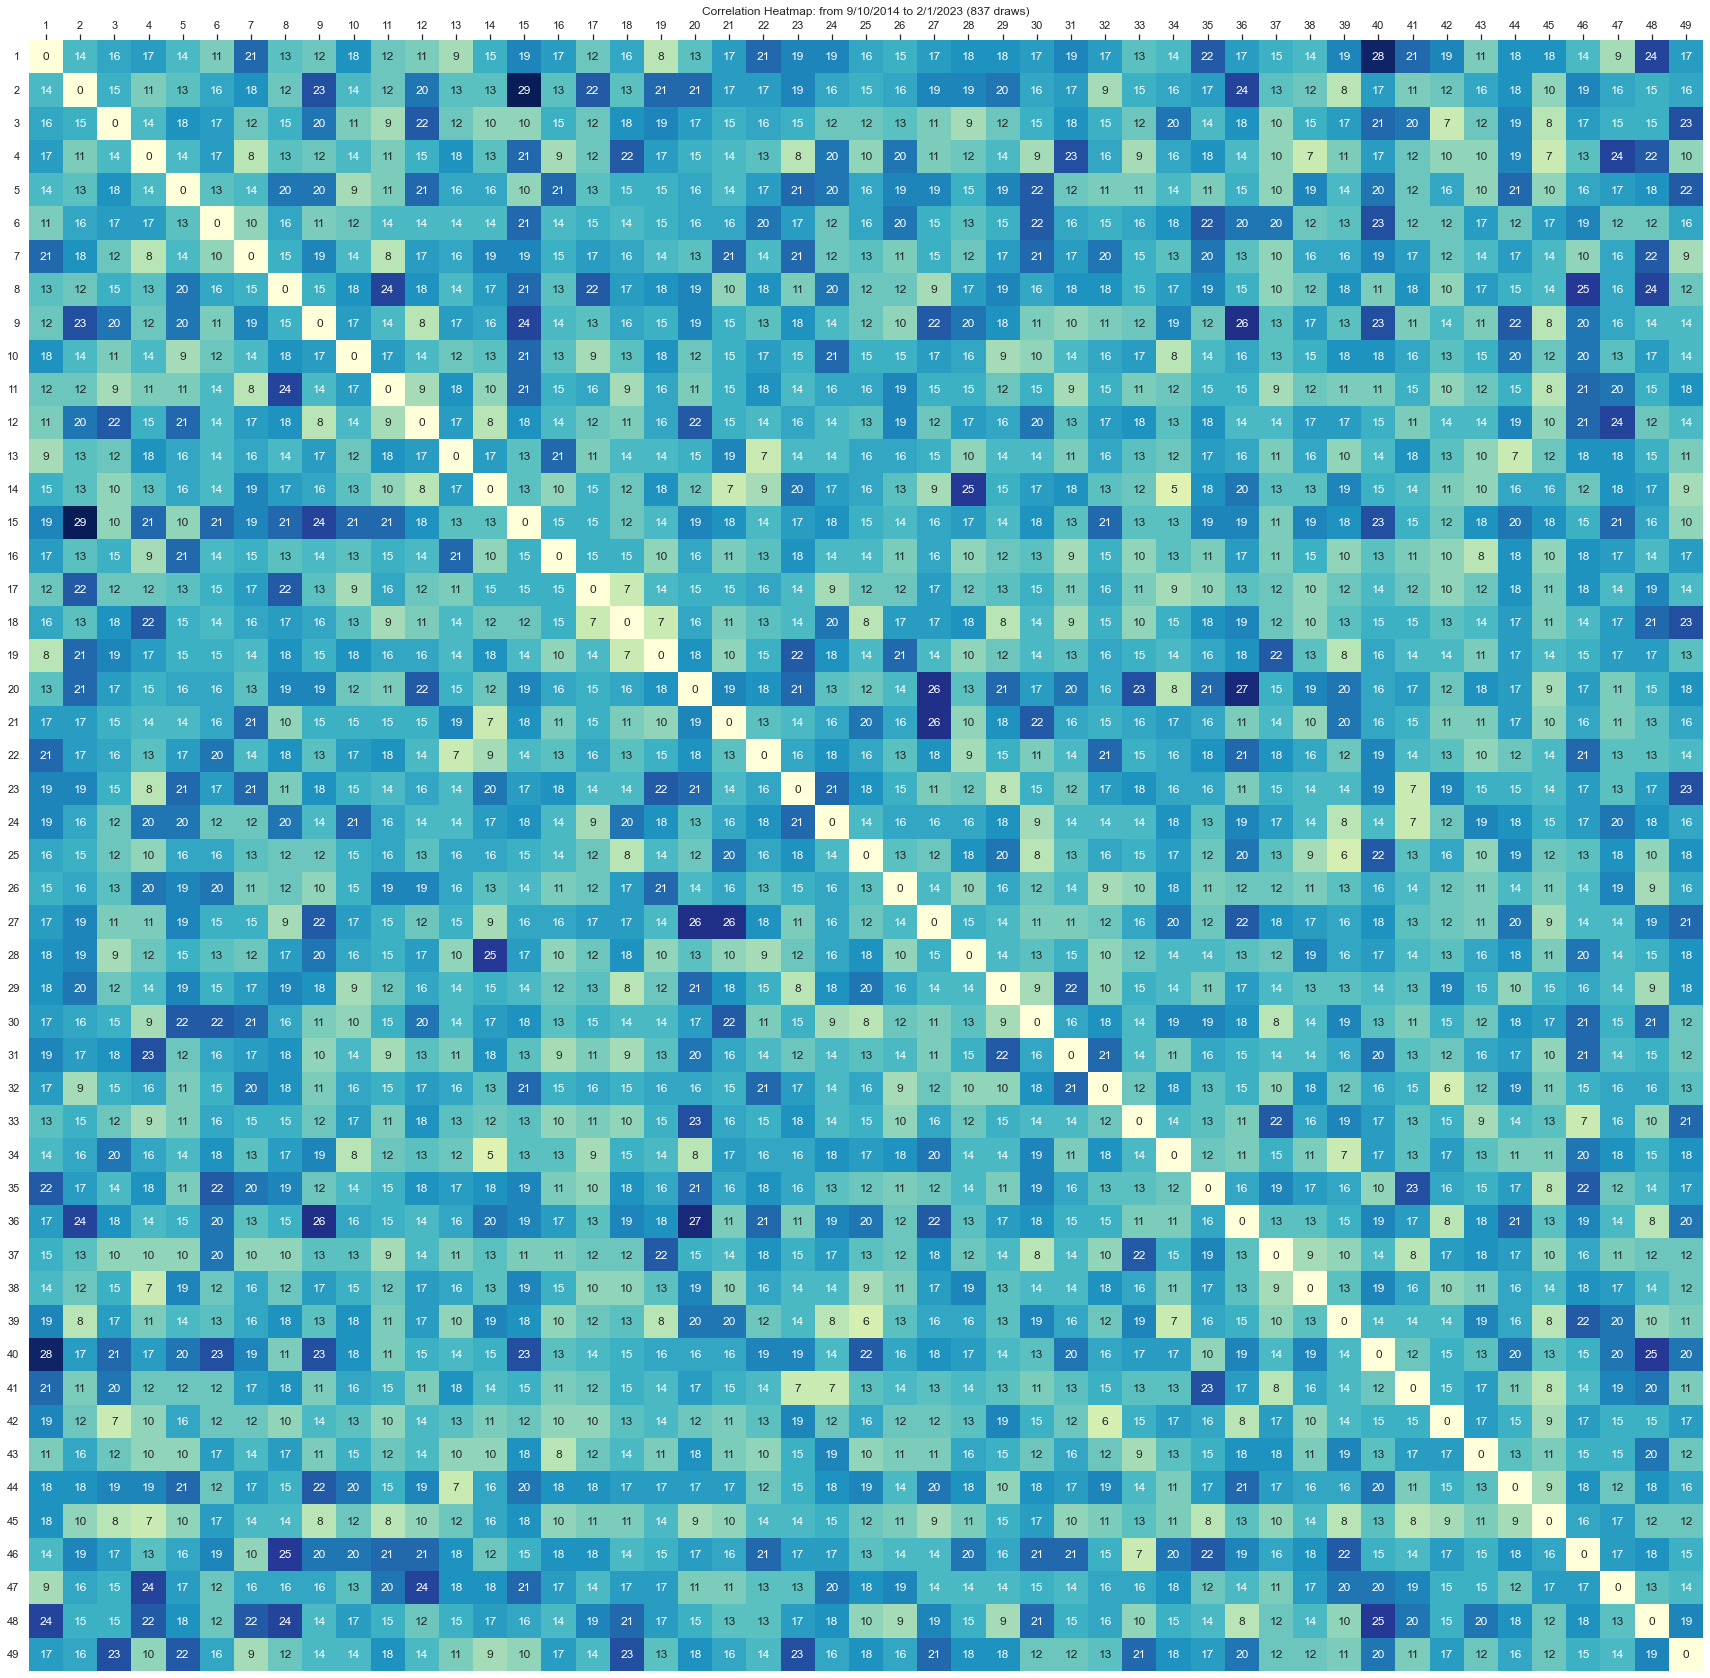

In [6]:
plt.figure(figsize=(30,30))
sns.set(rc={'axes.facecolor':'white'})
corrmap2014 = sns.heatmap(matrix2014, cmap="YlGnBu", annot=True, cbar=False)
corrmap2014.set_title('Correlation Heatmap: from 9/10/2014 to 2/1/2023 (837 draws)')
corrmap2014.xaxis.set_ticks_position("top") # set x axis ticks to the top
corrmap2014.set_yticklabels(corrmap2014.get_yticklabels(), rotation = 0) # make sure y axis ticks are upright
corrmap2014

#corrmap2014.get_figure().savefig('corrmap2014 02012023.png', bbox_inches='tight', dpi=300) # export figure

<AxesSubplot:>

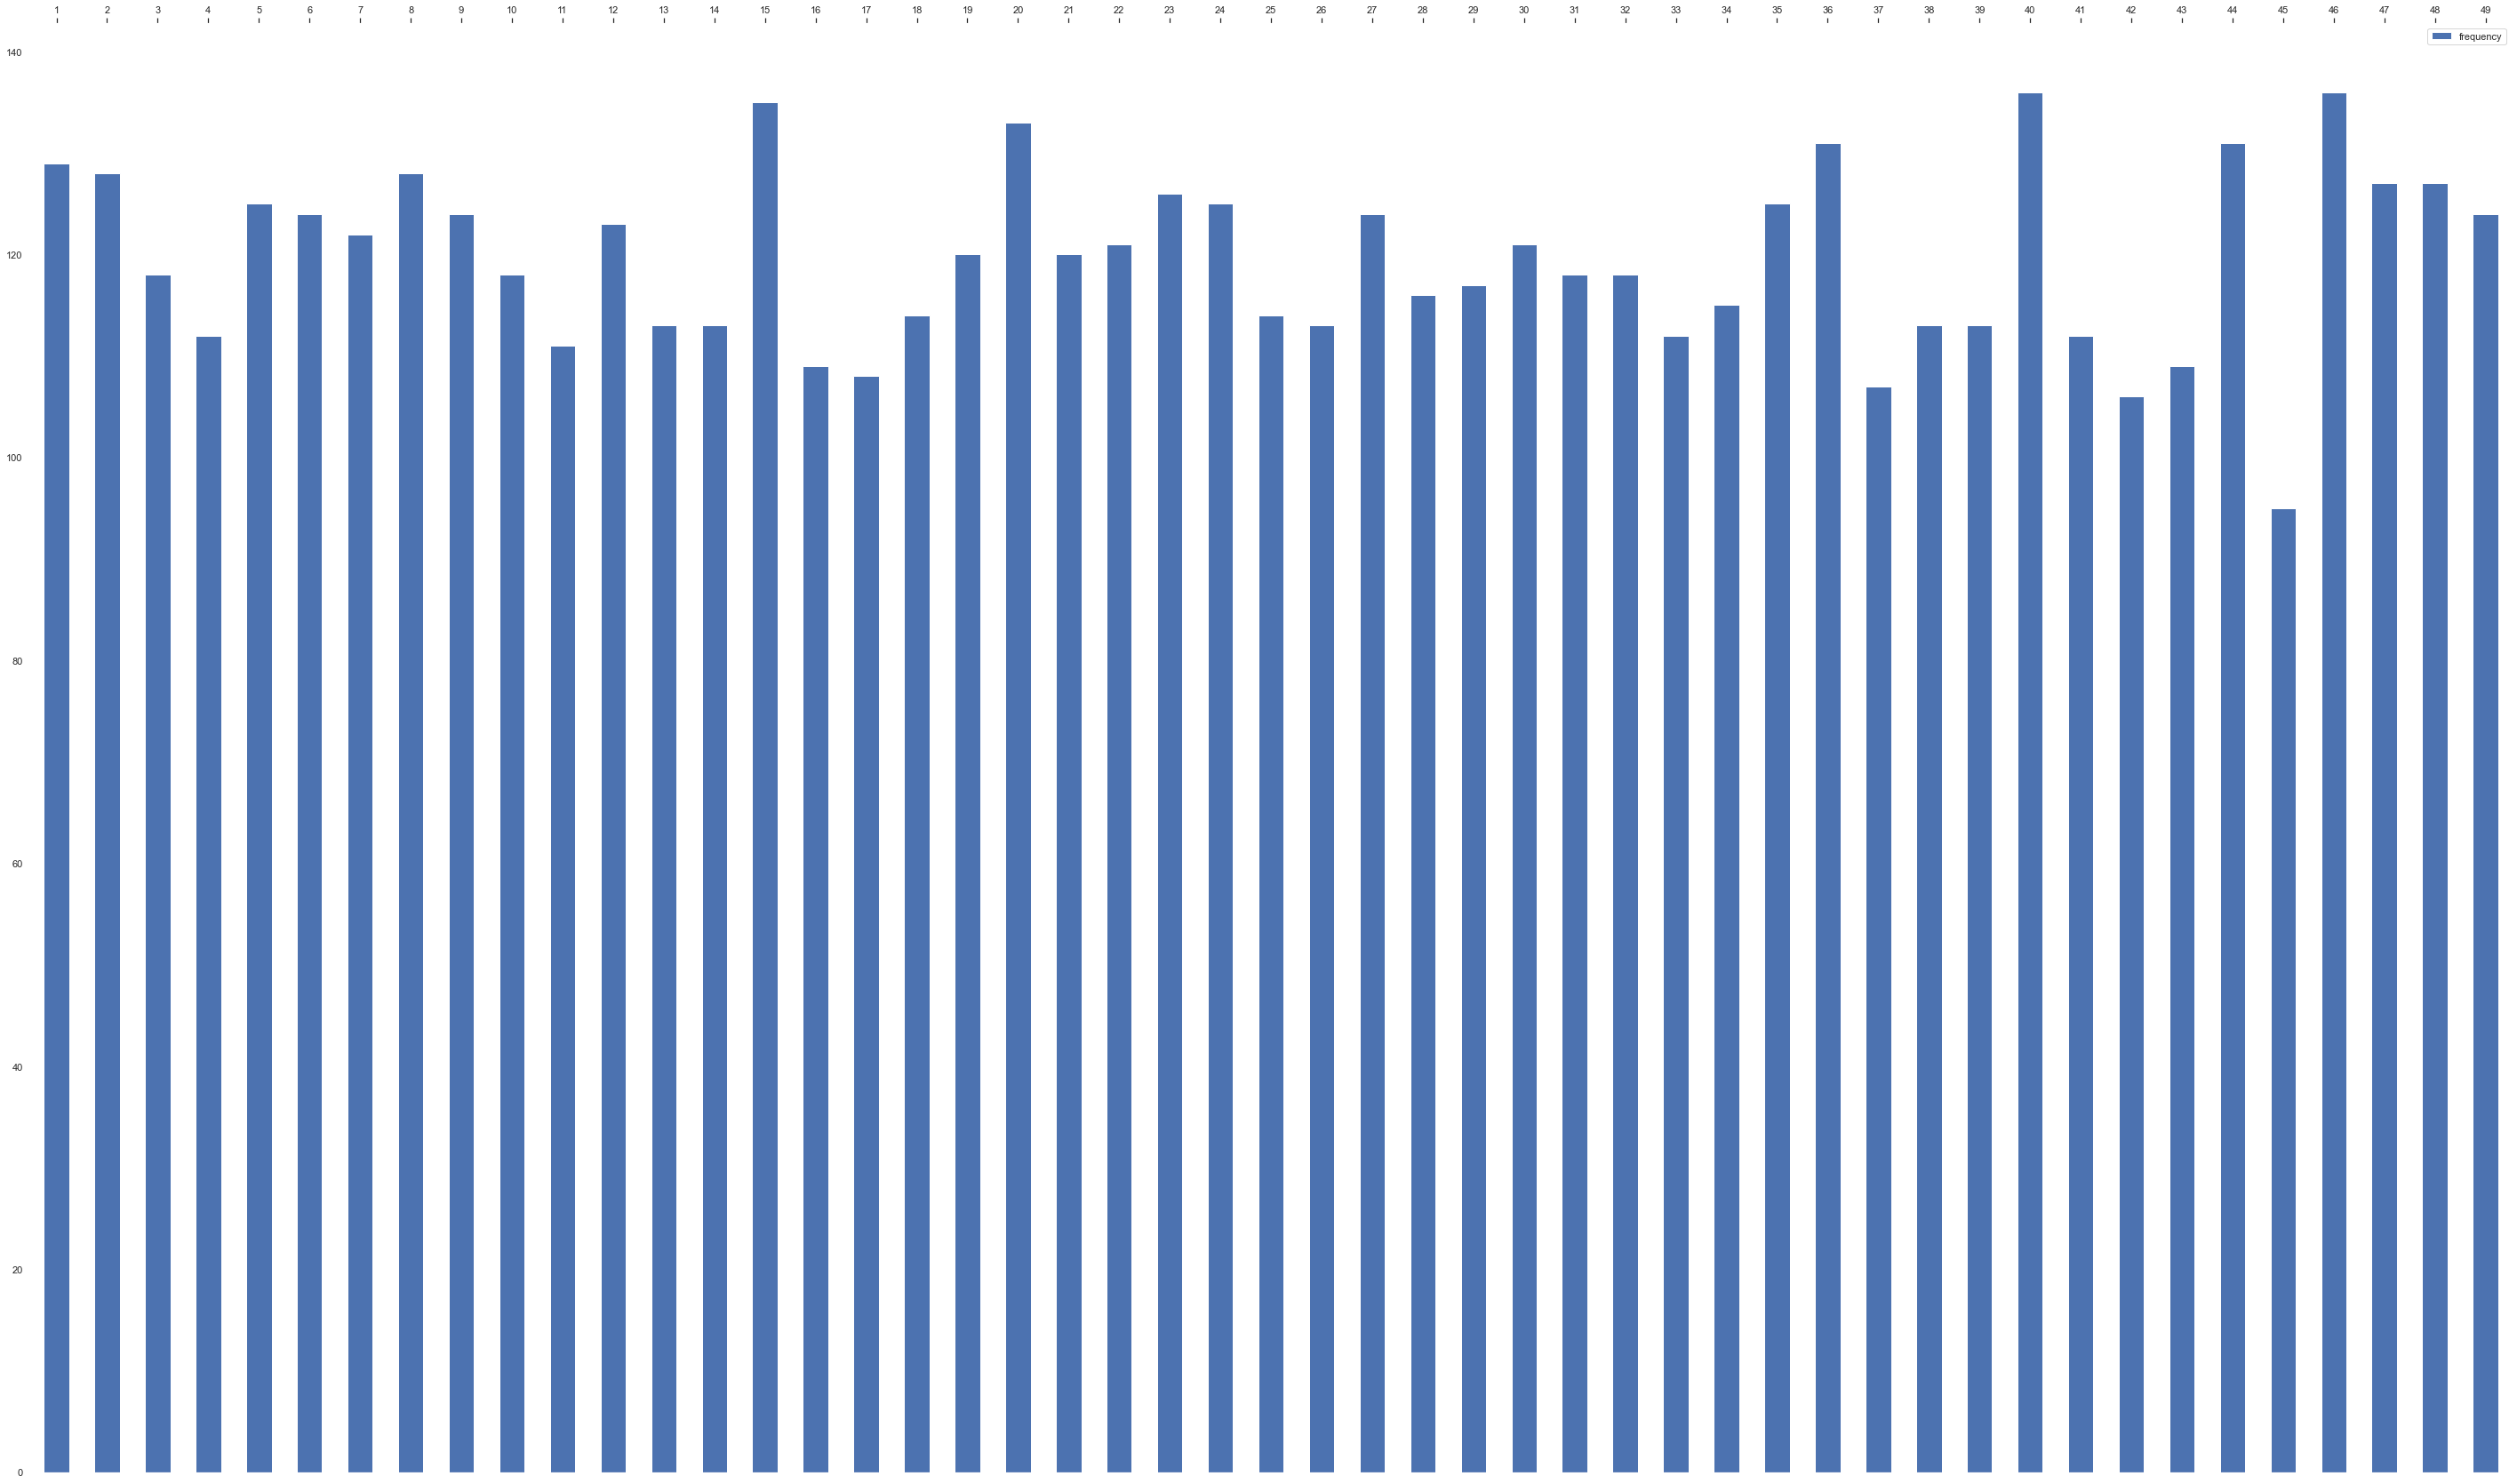

In [7]:
# Frequency analysis
df_freq2014 = pd.DataFrame(data=freqlist2014, index = [i for i in range(1,50)], columns=['frequency'])

freqplot2014 = df_freq2014.plot.bar(figsize=(50,30))
freqplot2014.xaxis.tick_top()
freqplot2014
#freqplot2014.get_figure().savefig('freqchart2014.png', bbox_inches='tight', dpi=300) # export figure

In [8]:
# Sums of every draw analysis

# List of sums for all draws
drawsums2014 = []
for eachrow in row_list_2014:
    drawsums2014.append(sum([i for i in eachrow]))
print(drawsums2014)

# List of dates for all draws
dates_list2014 = []
for index, rows in df2014.iterrows():
    dates_list2014.append(rows['Date'])
print(dates_list2014)

[160, 197, 208, 131, 205, 140, 165, 179, 114, 179, 167, 123, 147, 162, 182, 187, 206, 161, 174, 206, 170, 148, 145, 99, 200, 147, 186, 268, 193, 188, 144, 207, 192, 135, 128, 225, 102, 126, 217, 145, 206, 154, 193, 189, 172, 144, 182, 221, 199, 161, 164, 181, 122, 188, 217, 227, 196, 148, 160, 151, 207, 221, 187, 171, 138, 144, 221, 206, 128, 181, 167, 141, 189, 181, 243, 154, 150, 130, 214, 153, 133, 133, 123, 197, 260, 201, 204, 204, 176, 158, 175, 190, 183, 108, 168, 217, 144, 190, 159, 145, 171, 142, 179, 167, 213, 121, 123, 227, 128, 228, 174, 210, 226, 177, 127, 173, 121, 200, 207, 158, 145, 202, 140, 202, 224, 180, 198, 176, 221, 217, 163, 174, 252, 243, 118, 152, 221, 204, 176, 118, 183, 206, 158, 168, 171, 193, 200, 139, 164, 161, 204, 192, 173, 100, 194, 116, 153, 108, 240, 142, 129, 176, 181, 123, 188, 164, 146, 160, 197, 179, 153, 137, 176, 155, 171, 156, 188, 201, 146, 192, 241, 105, 122, 156, 176, 161, 167, 100, 196, 226, 176, 166, 123, 220, 113, 147, 170, 217, 176, 159, 

174.38470728793308


C:\Users\rateo\AppData\Local\Temp\ipykernel_13984\1938751607.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  sumschart2014.set_xticklabels(dates_list2014, size = 3, rotation=90)


<AxesSubplot:title={'center':'Draw sums: from 9/10/2014 to 2/1/2023. Grand mean sum: 174.38470728793308'}>

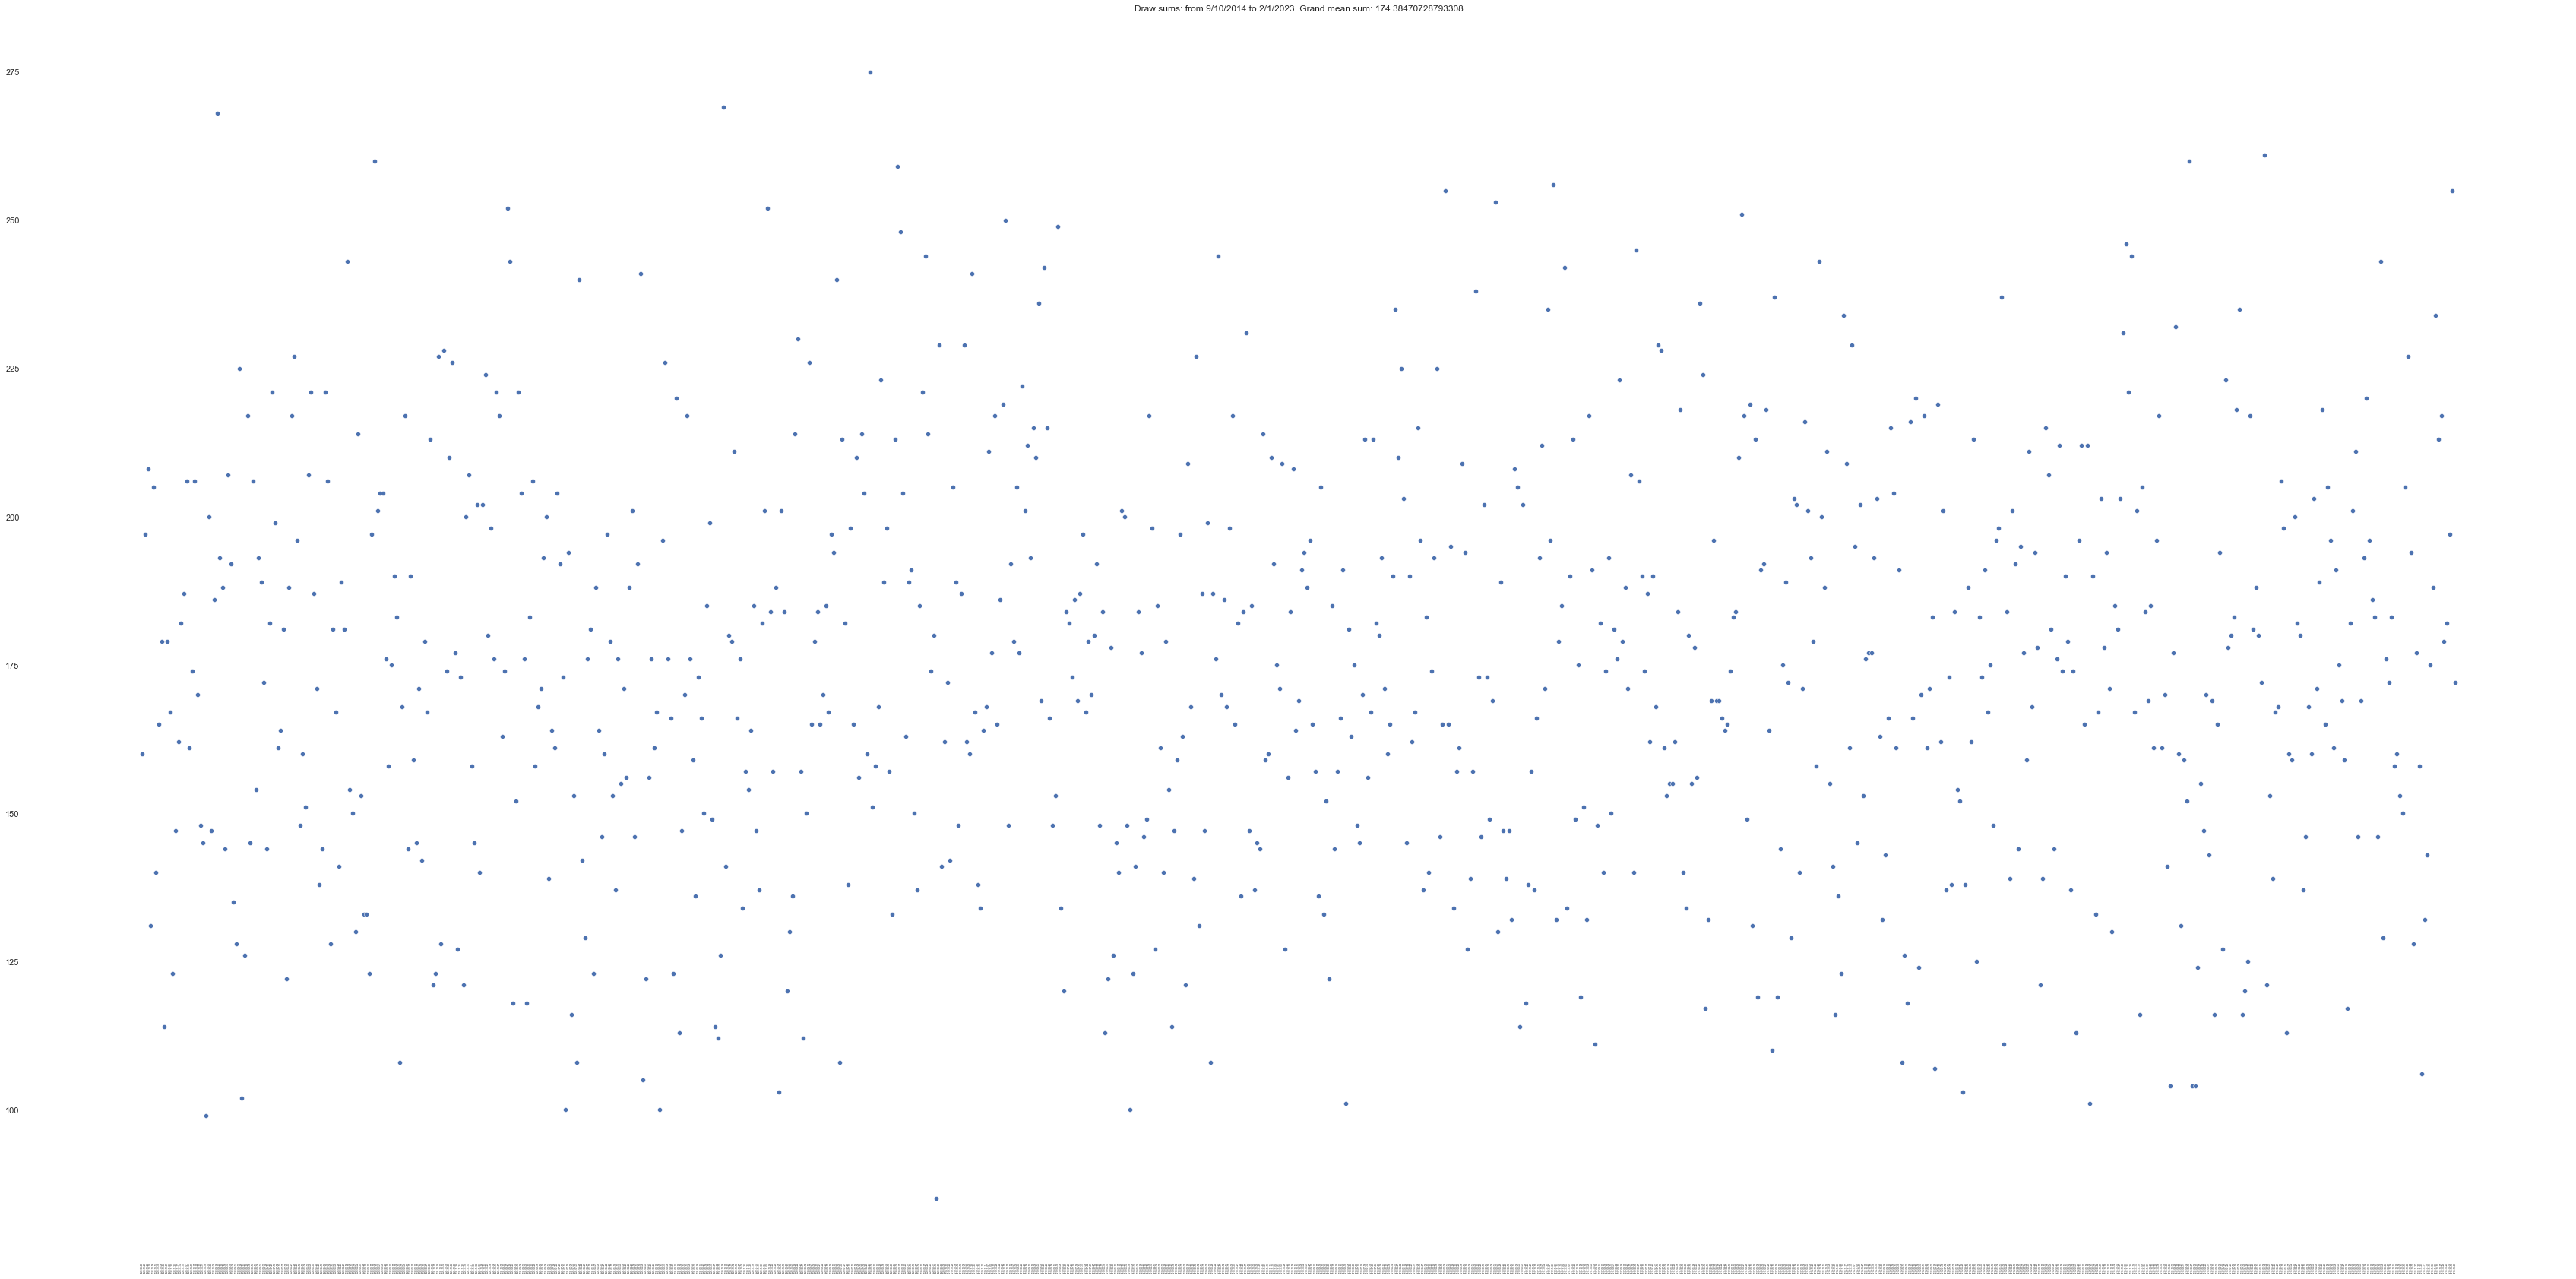

In [9]:
mean2014 = 0
for i in drawsums2014:
    mean2014 += i
mean2014 = mean2014/len(drawsums2014)
print(mean2014)

plt.figure(figsize=(60,30))
sumschart2014 = sns.scatterplot(x=dates_list2014, y=drawsums2014)
sumschart2014.set_xticklabels(dates_list2014, size = 3, rotation=90)
sumschart2014.set_title(f'Draw sums: from 9/10/2014 to 2/1/2023. Grand mean sum: {mean2014}')
sumschart2014
#sumschart2014.get_figure().savefig('sumschart2014 02012023.png', bbox_inches='tight', dpi=450) # export figure

In [10]:
# Sets analysis (only for sets of 6. Will be more onerous for more number picks)
# Sets with highest frequency sum: highest occurrences theory

no_of_other_numbers = 5 # only 6 numbers per set will be considered
lucky_df = pd.DataFrame(columns=['set','freq_sum']) # initialise

for i in range (1,50):
    freq_sum = df_freq2014.loc[i]['frequency'] # freq of this number
    other_numbers = matrix2014.loc[[i]] # get the row across the matrix

    set = other_numbers.transpose().sort_values(by=i, ascending=False).head(no_of_other_numbers) # get only the top numbers

    best_numbers = [i]
    best_numbers.extend(set.index.tolist())

    freq_sum += set[i].sum() # calculate sum

    new_row = pd.Series({'set': best_numbers,'freq_sum': freq_sum})
    lucky_df = pd.concat([lucky_df, new_row.to_frame().T], ignore_index=True)
    
lucky_df

,set,freq_sum
0,"[1, 40, 48, 35, 22, 7]",245
1,"[2, 15, 36, 9, 17, 20]",247
2,"[3, 49, 12, 40, 41, 34]",224
3,"[4, 47, 31, 48, 18, 15]",224
4,"[5, 49, 30, 44, 16, 12]",232
5,"[6, 40, 35, 30, 15, 26]",232
6,"[7, 48, 1, 23, 30, 21]",228
7,"[8, 46, 48, 11, 17, 15]",244
8,"[9, 36, 15, 2, 40, 27]",242
9,"[10, 15, 24, 46, 44, 1]",218


In [11]:
lucky_df.sort_values(by='freq_sum', ascending=False).head(10)

,set,freq_sum
39,"[40, 1, 48, 6, 15, 9]",258
14,"[15, 2, 9, 40, 10, 4]",253
19,"[20, 36, 27, 33, 12, 35]",252
35,"[36, 20, 9, 2, 27, 44]",251
45,"[46, 8, 39, 35, 22, 30]",247
1,"[2, 15, 36, 9, 17, 20]",247
0,"[1, 40, 48, 35, 22, 7]",245
47,"[48, 40, 1, 8, 4, 7]",244
7,"[8, 46, 48, 11, 17, 15]",244
8,"[9, 36, 15, 2, 40, 27]",242


In [16]:
# Sets analysis (only for sets of 6. Will be more onerous for more number picks)
# Sets with lowest frequency sum: mean reversion theory
# Need to remove the first number itself from the count

no_of_other_numbers = 5 # only 6 numbers per set will be considered
lucky_df = pd.DataFrame(columns=['set','freq_sum']) # initialise

for i in range (1,50):
    freq_sum = df_freq2014.loc[i]['frequency']
    other_numbers = matrix2014.loc[[i]].drop(i, axis=1) # get the row across the matrix, minus the starting value

    set = other_numbers.transpose().sort_values(by=i, ascending=True).head(no_of_other_numbers) # get only the lowest numbers

    best_numbers = [i]
    best_numbers.extend(set.index.tolist())

    freq_sum += set[i].sum() # calculate sum

    new_row = pd.Series({'set': best_numbers,'freq_sum': freq_sum})
    lucky_df = pd.concat([lucky_df, new_row.to_frame().T], ignore_index=True)
    
lucky_df

,set,freq_sum
0,"[1, 19, 47, 13, 6, 43]",177
1,"[2, 39, 32, 45, 4, 41]",177
2,"[3, 42, 45, 28, 11, 37]",161
3,"[4, 45, 38, 7, 23, 33]",151
4,"[5, 10, 37, 45, 43, 15]",174
5,"[6, 7, 1, 9, 47, 44]",180
6,"[7, 4, 11, 49, 46, 6]",167
7,"[8, 27, 42, 37, 21, 40]",178
8,"[9, 45, 12, 31, 26, 43]",171
9,"[10, 34, 29, 5, 17, 30]",163


In [17]:
lucky_df.sort_values(by='freq_sum', ascending=True).tail(10)

,set,freq_sum
0,"[1, 19, 47, 13, 6, 43]",177
7,"[8, 27, 42, 37, 21, 40]",178
43,"[44, 13, 45, 29, 41, 34]",179
35,"[36, 48, 42, 33, 34, 21]",180
5,"[6, 7, 1, 9, 47, 44]",180
46,"[47, 1, 37, 21, 20, 44]",181
19,"[20, 34, 45, 47, 11, 25]",184
14,"[15, 49, 3, 5, 37, 18]",188
45,"[46, 33, 7, 14, 4, 25]",191
39,"[40, 35, 11, 8, 41, 16]",193


In [ ]:
# WORKING

In [5]:
dfsample = pd.DataFrame([[1,2,3],[4,5,2]])
dfsample

,0,1,2
0,1,2,3
1,4,5,2


In [9]:
#matrix = pd.DataFrame(data = [[0 for j in range(1,10)] for i in range(1,10)], index = [i for i in range(1,10)], columns = [i for i in range(1,10)])
matrixsample = pd.DataFrame(data = [[0 for j in range(1,6)] for i in range(1,6)], index = [i for i in range(1,6)], columns = [i for i in range(1,6)])
matrixsample

,1,2,3,4,5
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
5,0,0,0,0,0


In [89]:
df_freq2014[df_freq2014['frequency'] == first_no_freq]

,frequency
40,136
46,136


In [90]:
matrix2014.loc[[1]]

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
1,0,14,16,17,14,11,21,13,12,18,...,28,21,19,11,18,18,14,9,24,17


In [ ]:
first_no_freq = df_freq2014.max(axis='index')[0] # find which is the highest frequency which a number has appeared
first_no = df_freq2014[df_freq2014['frequency'] == first_no_freq].first_valid_index() # first index (ie number) with the highest freq. 40 and 46.


In [34]:
# numpy methods
import numpy as np
array = np.zeros((49,49)) #array([[i for i in range(1,50)],[i for i in range(1,50)]])
array = np.array([[j for j in range(1,5)] for i in range(1,5)]) # stop is exclusive. indexing starts from 0

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [95]:
# Tried doing it in pandas, but hard to extract image
ax = matrix.style.background_gradient(axis=None, cmap="YlGnBu")
ax

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
1,0,25,30,28,31,28,31,30,23,33,29,29,30,27,33,35,25,32,22,23,29,45,31,34,32,31,30,30,27,27,38,33,28,33,36,35,29,39,31,34,39,38,23,32,36,14,9,24,17
2,25,0,27,24,25,28,24,25,34,25,27,29,24,25,43,25,33,27,35,30,34,30,34,32,33,22,32,31,31,21,28,19,26,24,25,36,21,20,23,27,17,28,28,30,19,19,16,15,16
3,30,27,0,30,27,28,34,25,37,21,19,33,25,25,21,22,27,25,31,21,26,29,25,26,22,23,24,18,25,25,36,24,22,28,22,30,26,23,27,27,36,26,24,27,25,17,15,15,23
4,28,24,30,0,26,32,25,25,35,27,24,31,31,23,33,27,31,39,26,24,27,35,22,37,19,37,30,20,33,23,36,27,22,24,32,25,24,14,29,28,27,30,27,35,23,13,24,22,10
5,31,25,27,26,0,25,26,31,34,18,26,34,28,29,31,36,29,29,27,30,25,35,34,32,26,34,35,25,31,38,24,21,26,30,18,31,24,30,26,32,24,24,20,28,26,16,17,18,22
6,28,28,28,32,25,0,26,33,23,32,31,25,28,25,33,24,26,29,26,33,29,39,36,21,26,38,30,32,29,40,41,30,31,29,37,33,31,23,28,31,24,23,29,32,32,19,12,12,16
7,31,24,34,25,26,26,0,28,40,35,23,30,32,29,32,30,32,36,29,21,34,24,34,29,22,30,32,26,33,33,34,31,26,24,33,32,23,31,27,24,31,28,26,28,35,10,16,22,9
8,30,25,25,25,31,33,28,0,29,31,35,39,30,35,36,30,39,27,35,29,34,36,24,36,25,29,25,29,34,30,36,34,29,26,30,30,21,24,34,27,30,23,35,25,29,25,16,24,12
9,23,34,37,35,34,23,40,29,0,31,28,25,26,37,35,24,37,33,29,30,27,31,38,24,21,27,39,39,37,33,30,24,29,30,23,34,27,28,29,36,28,22,28,40,26,20,16,14,14
10,33,25,21,27,18,32,35,31,31,0,36,33,27,23,38,28,28,24,27,26,32,35,33,30,27,29,32,25,28,23,35,29,31,26,24,31,26,29,28,35,31,34,24,32,28,20,13,17,14
